Sampling frequency: 8000
Signal length (samples): 466063
Duration (seconds): 58.257875


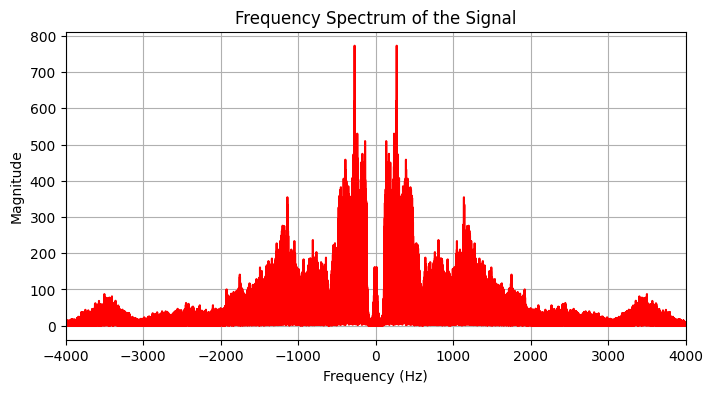

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import periodogram

# Load audio
fs, x = wavfile.read("speech.wav")  # replace with your file

# Convert to float
x = x.astype(np.float32)

# If stereo, keep one channel
if x.ndim > 1:
    x = x[:, 0]

# Normalize
x = x / np.max(np.abs(x))

print("Sampling frequency:", fs)
print("Signal length (samples):", len(x))
print("Duration (seconds):", len(x) / fs)


# FFT computation
X = np.fft.fft(x)
X = np.fft.fftshift(X)

# Frequency axis
freqs = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs))

# Magnitude
magnitude = np.abs(X)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(freqs, magnitude, color='red')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum of the Signal")
plt.xlim(-fs/2, fs/2)
plt.grid(True)
plt.show()


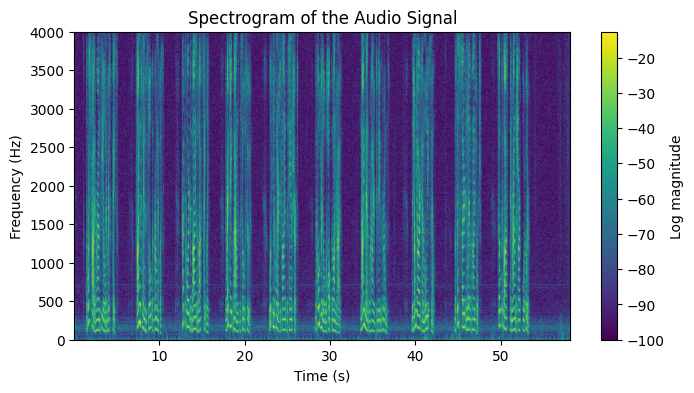

In [ ]:
from scipy.signal import spectrogram

# Compute spectrogram
f, t, Sxx = spectrogram(
    x,
    fs=fs,
    window='hann',
    nperseg=1024,
    noverlap=512,
    scaling='spectrum'
)

plt.figure(figsize=(8, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.colorbar(label="Log magnitude")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.title("Spectrogram of the Audio Signal")
plt.ylim(0, fs/2)
plt.show()

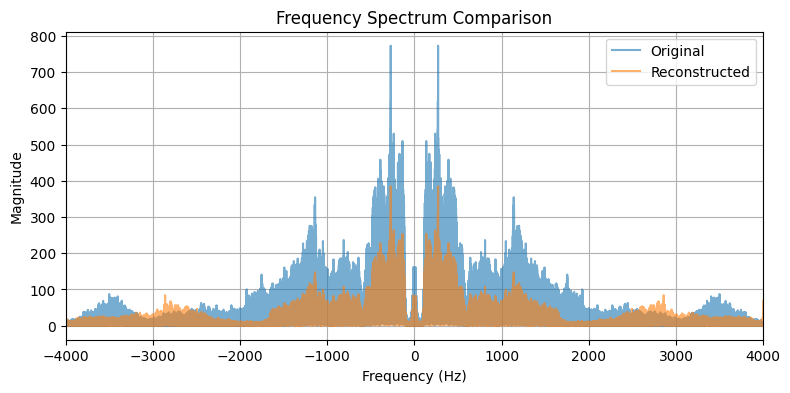

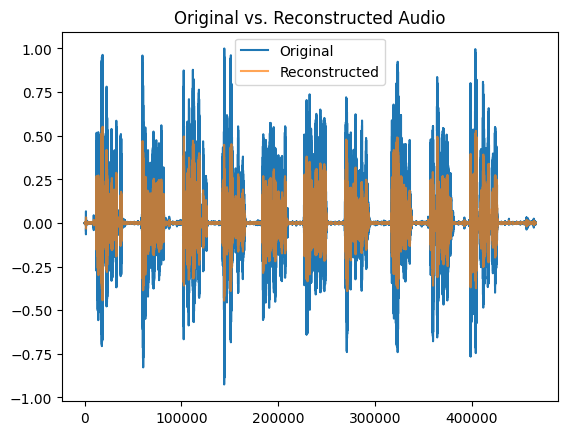

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, decimate, upfirdn

# Filter parameters
fs = 8000  # Sampling frequency
cutoff = fs / 4  # Cutoff frequency at fs/4
numtaps = 64  # Number of filter taps

# Low-pass filter (FIR)
lp_filter = firwin(numtaps, cutoff, fs=fs)

# High-pass filter (complement of low-pass)
hp_filter = -lp_filter
hp_filter[numtaps // 2] += 1  # Frequency shift to create high-pass

# Apply filters to split into sub-bands
low_band = lfilter(lp_filter, 1.0, x)
high_band = lfilter(hp_filter, 1.0, x)

# Downsample each band by 2
low_band_ds = decimate(low_band, 2)
high_band_ds = decimate(high_band, 2)

# Quantization example: 8 bits low band, 4 bits high band (just a simple uniform quantization here)
low_band_q = np.round(low_band_ds * 127) / 127  # 8-bit quantization
high_band_q = np.round(high_band_ds * 7) / 7  # 4-bit quantization

# Upsample back (by 2) and reconstruct
low_band_us = upfirdn([1], low_band_q, up=2)
high_band_us = upfirdn([1], high_band_q, up=2)

# Re-filter the upsampled bands to reconstruct
low_band_rec = lfilter(lp_filter, 1.0, low_band_us)
high_band_rec = lfilter(hp_filter, 1.0, high_band_us)

# Align lengths (upsampling adds extra zeros at the end)
min_len = min(len(low_band_rec), len(high_band_rec))
reconstructed = low_band_rec[:min_len] + high_band_rec[:min_len]


# FFT of original
X_orig = np.fft.fftshift(np.fft.fft(x))
freqs = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs))

# FFT of reconstructed
X_rec = np.fft.fftshift(np.fft.fft(reconstructed))

# Make same length if needed
min_len = min(len(X_orig), len(X_rec))
X_orig = X_orig[:min_len]
X_rec = X_rec[:min_len]
freqs = freqs[:min_len]

plt.figure(figsize=(9, 4))
plt.plot(freqs, np.abs(X_orig), label="Original", alpha=0.6)
plt.plot(freqs, np.abs(X_rec), label="Reconstructed", alpha=0.6)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum Comparison")
plt.xlim(-fs/2, fs/2)
plt.legend()
plt.grid(True)
plt.show()

# Plot original and reconstructed to compare
plt.figure()
plt.plot(x, label='Original')
plt.plot(reconstructed, label='Reconstructed', alpha=0.7)
plt.legend()
plt.title('Original vs. Reconstructed Audio')
plt.show()




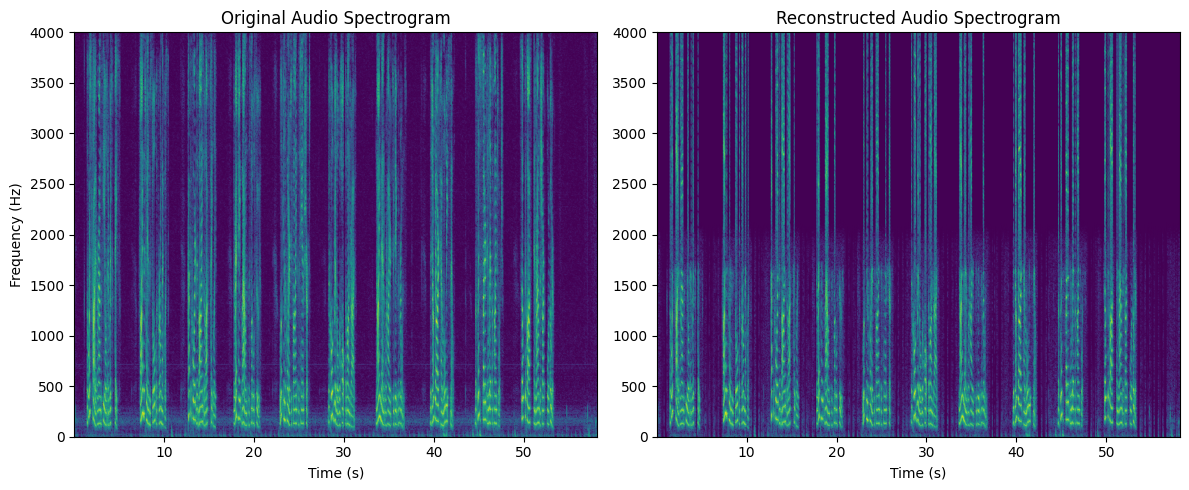

In [ ]:
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
import numpy as np

# Spectrogram of original
f1, t1, S1 = spectrogram(x, fs, nperseg=1024, noverlap=512)

# Spectrogram of reconstructed
f2, t2, S2 = spectrogram(reconstructed, fs, nperseg=1024, noverlap=512)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pcolormesh(t1, f1, 10*np.log10(S1 + 1e-10), shading='gouraud')
plt.title("Original Audio Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.ylim(0, fs/2)

plt.subplot(1, 2, 2)
plt.pcolormesh(t2, f2, 10*np.log10(S2 + 1e-10), shading='gouraud')
plt.title("Reconstructed Audio Spectrogram")
plt.xlabel("Time (s)")
plt.ylim(0, fs/2)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Ensure original and reconstructed are the same length
min_len = min(len(x), len(reconstructed))
original = x[:min_len]
reconstructed = reconstructed[:min_len]

# Mean Squared Error (MSE)
mse = np.mean((original - reconstructed)**2)

# Signal-to-Noise Ratio (SNR) in dB
signal_power = np.mean(original**2)
noise_power = mse
snr_db = 10 * np.log10(signal_power / noise_power)

print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Signal-to-Noise Ratio (SNR): {snr_db:.2f} dB")


Mean Squared Error (MSE): 0.010180
Signal-to-Noise Ratio (SNR): -0.65 dB


In [ ]:
from scipy.io.wavfile import write
from IPython.display import Audio

# Scale reconstructed signal to -1 to 1 (if needed)
reconstructed = reconstructed / np.max(np.abs(reconstructed))

# Write to WAV file (16-bit PCM)
write("reconstructed.wav", fs, (reconstructed * 32767).astype(np.int16))

# Play the audio in notebook (or just open the WAV file in a player)
Audio("reconstructed.wav", rate=fs)



In [ ]:
# Original audio parameters
original_fs = 8000  # Original sampling rate in Hz
original_bits = 16  # Original bits per sample
channels = 1  # Mono

# Original bit rate (bits per second)
original_bit_rate = original_fs * original_bits * channels

# After processing parameters
low_band_fs = original_fs / 2  # Downsampled by 2
high_band_fs = original_fs / 2  # Same downsampling

# Bits after quantization
low_band_bits = 8   # Example: 8 bits for low band
high_band_bits = 4   # Example: 4 bits for high band

# Bit rates of sub-bands
low_band_bit_rate = low_band_fs * low_band_bits * channels
high_band_bit_rate = high_band_fs * high_band_bits * channels

# Total compressed bit rate
compressed_bit_rate = low_band_bit_rate + high_band_bit_rate

# Compression ratio (original / compressed)
compression_ratio = original_bit_rate / compressed_bit_rate

# Print results
print(f"Original Bit Rate: {original_bit_rate / 1000} kbps")
print(f"Compressed Bit Rate: {compressed_bit_rate / 1000} kbps")
print(f"Compression Ratio: {compression_ratio:.2f}")


Original Bit Rate: 128.0 kbps
Compressed Bit Rate: 48.0 kbps
Compression Ratio: 2.67
